In [31]:
import math
import random
import copy

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Apply RevIN, preprocess data

In [32]:
SEEDS = [0, 1, 2, 3, 4]

P = 12
HIDDEN_DIM = 50
LEARNING_RATE = 0.01
MAX_EPOCHS = 500
PATIENCE = 30

NUM_LAYERS = 1
DROPOUT = 0.0
BATCH_SIZE = 32

In [33]:
df = pd.read_csv("fred.csv")

df["UNRATE"] = df["UNRATE"].interpolate(method="linear")
df["CPIAUCSL"] = df["CPIAUCSL"].interpolate(method="linear")

transformed_df = pd.DataFrame({
    "RPI": np.log(df["RPI"]).diff(),
    "UNRATE": df["UNRATE"].diff(),
    "DPCERA3M086SBEA": np.log(df["DPCERA3M086SBEA"]).diff(),
    "GS5": df["GS5"].diff(),
    "CPIAUCSL": np.log(df["CPIAUCSL"]).diff().diff()
})

transformed_df = transformed_df.dropna().reset_index(drop=True)

series_names = [
    "CPIAUCSL",
    "GS5",
    "UNRATE",
    "RPI",
    "DPCERA3M086SBEA"
]

In [34]:
def normalize(x):
    mean = x.mean(dim=1, keepdim=True)
    std = x.std(dim=1, keepdim=True, unbiased=False)

    return (x - mean) / (std + 1e-5), mean, std


def denormalize(x, mean, std):
    return x * (std.squeeze(1) + 1e-5) + mean.squeeze(1)

In [35]:
def make_windows(series, p):
    values = series.dropna().to_numpy(dtype=np.float32)

    X = []
    y = []

    for i in range(p, len(values)):
        X.append(values[i-p:i])
        y.append(values[i])

    X = torch.tensor(np.array(X)).unsqueeze(2)
    y = torch.tensor(np.array(y)).unsqueeze(1)

    return X, y

In [36]:
def split_data(X, y):
    n = len(X)

    train_end = int(0.70 * n)
    val_end = int(0.80 * n)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [37]:
class LSTMAttention(nn.Module):
    def __init__(self, input_dim = 1, hidden_dim = 64, num_layers = 1, dropout = 0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_size = input_dim, hidden_size = hidden_dim, num_layers = num_layers, batch_first = True, dropout = dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        #x [batch_size, # of lags, input_dim]
        hidden_states, _ = self.lstm(x)

        q = hidden_states[:, -1, :]
        # attention scores is the sum of dot products of queries and keys / sqrt(dimension of hidden state)
        scores = torch.bmm(hidden_states, q.unsqueeze(2)).squeeze(2)
        scores = scores/math.sqrt(self.hidden_dim)

        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), hidden_states).squeeze(1)
        prediction =self.fc(context) 

        return prediction, attention_weights    

In [38]:
def evaluate_model(model, X, y):
    model.eval()

    with torch.no_grad():
        X_norm, mean, std = normalize(X)

        pred_norm, attention_weights = model(X_norm)

        predictions = denormalize(
            pred_norm,
            mean,
            std
        )

        y_true = y.cpu().numpy().ravel()
        y_pred = predictions.cpu().numpy().ravel()

        mse = mean_squared_error(
            y_true,
            y_pred
        )

    return mse, predictions, attention_weights

In [39]:
def train_model(X_train, y_train, X_val, y_val, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = LSTMAttention(
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    best_val_mse = float("inf")
    best_state = None
    best_epoch = 0
    patience_counter = 0

    for epoch in range(MAX_EPOCHS):
        model.train()

        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()

            x_norm, mean, std = normalize(x_batch)

            y_norm = (
                y_batch - mean.squeeze(1)
            ) / (
                std.squeeze(1) + 1e-5
            )

            pred_norm, _ = model(x_norm)

            loss = loss_fn(pred_norm, y_norm)

            loss.backward()
            optimizer.step()

        val_mse, _, _ = evaluate_model(model, X_val, y_val)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    return model, best_epoch

In [40]:
def run_ar1(
    X_train,
    y_train,
    X_test,
    y_test
):

    X_train_ar = (
        X_train[:, -1, 0]
        .numpy()
        .reshape(-1, 1)
    )

    X_test_ar = (
        X_test[:, -1, 0]
        .numpy()
        .reshape(-1, 1)
    )

    y_train_ar = y_train.numpy().ravel()
    y_test_ar = y_test.numpy().ravel()

    model = LinearRegression()

    model.fit(
        X_train_ar,
        y_train_ar
    )

    predictions = model.predict(
        X_test_ar
    )

    mse = mean_squared_error(
        y_test_ar,
        predictions
    )

    return mse

In [ ]:
all_results = []

predictions_store = {}
attention_store = {}
y_test_store = {}

for name in series_names:

    X, y = make_windows(
        transformed_df[name],
        P
    )

    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    ) = split_data(
        X,
        y
    )

    ar_mse = run_ar1(
        X_train,
        y_train,
        X_test,
        y_test
    )

    y_test_store[name] = y_test.cpu().numpy().ravel()

    for seed in SEEDS:

        model, best_epoch = train_model(
            X_train,
            y_train,
            X_val,
            y_val,
            seed
        )

        lstm_mse, predictions, attention_weights = evaluate_model(
            model,
            X_test,
            y_test
        )

        predictions_store[(name, seed)] = (
            predictions.cpu().numpy().ravel()
        )

        attention_store[(name, seed)] = (
            attention_weights.cpu().numpy()
        )

        all_results.append({
            "Series": name,
            "Seed": seed,
            "Best Epoch": best_epoch,
            "AR(1) MSE": ar_mse,
            "LSTM Attention MSE": lstm_mse
        })


all_results = pd.DataFrame(
    all_results
)

all_results

,Series,Seed,Best Epoch,AR(1) MSE,LSTM Attention MSE
0,CPIAUCSL,0,1,0.571411,1.947219
1,CPIAUCSL,1,86,0.571411,0.512887
2,CPIAUCSL,2,1,0.571411,2.265059
3,CPIAUCSL,3,1,0.571411,1.616785
4,CPIAUCSL,4,80,0.571411,0.547341
5,GS5,0,18,0.038561,0.053844
6,GS5,1,17,0.038561,0.045469
7,GS5,2,13,0.038561,0.042781
8,GS5,3,16,0.038561,0.042177
9,GS5,4,13,0.038561,0.045434


In [ ]:
seed_table = (
    all_results
    .pivot(
        index="Series",
        columns="Seed",
        values="LSTM Attention MSE"
    )
    .rename(columns={
        0: "Seed 0",seed_table = (
    all_results
    .pivot(
        index="Series",
        columns="Seed",
        values="LSTM Attention MSE"
    )
    .rename(columns={
        0: "Seed 0",
        1: "Seed 1",
        2: "Seed 2",
        3: "Seed 3",
        4: "Seed 4"
    })
)

summary = (
    all_results
    .groupby("Series")
    .agg(
        **{
            "Model Average": ("LSTM Attention MSE", "mean"),
            "AR(1)": ("AR(1) MSE", "first")
        }
    )
)

final_table = seed_table.join(summary)

final_table["Relative Performance"] = (
    final_table["Model Average"] / final_table["AR(1)"]
)

row_order = [
    "RPI",
    "UNRATE",
    "CPIAUCSL",
    "GS5",
    "DPCERA3M086SBEA"
]

final_table = final_table.loc[row_order]

final_table = final_table[
    [
        "Seed 0",
        "Seed 1",
        "Seed 2",
        "Seed 3",
        "Seed 4",
        "Model Average",
        "AR(1)",
        "Relative Performance"
    ]
]

final_table_rounded = final_table.round(6)
final_table_rounded
        1: "Seed 1",
        2: "Seed 2",
        3: "Seed 3",
        4: "Seed 4"
    })
)

summary = (
    all_results
    .groupby("Series")
    .agg(
        **{
            "Model Average": ("LSTM Attention MSE", "mean"),
            "AR(1)": ("AR(1) MSE", "first")
        }
    )
)

final_table = seed_table.join(summary)

final_table["Relative Performance"] = (
    final_table["Model Average"]
    / final_table["AR(1)"]
)

final_table = final_table[
    [
        "Seed 0",
        "Seed 1",
        "Seed 2",
        "Seed 3",
        "Seed 4",
        "Model Average",
        "AR(1)",
        "Relative Performance"
    ]
]

final_table.round(6)

,Seed 0,Seed 1,Seed 2,Seed 3,Seed 4,Model Average,AR(1),Relative Performance
Series,,,,,,,,
CPIAUCSL,1.947219,0.512887,2.265059,1.616785,0.547341,1.377858,0.571411,2.411327
DPCERA3M086SBEA,3.284897,2.384414,2.319144,4.198505,2.202546,2.877901,1.835406,1.567992
GS5,0.053844,0.045469,0.042781,0.042177,0.045434,0.045941,0.038561,1.191393
RPI,234029.406250,232274.500000,229288.703125,257962.046875,302515.750000,251214.081250,227844.000000,1.102571
UNRATE,1.139959,1.063725,1.189071,1.169341,1.115884,1.135596,0.773805,1.467548


In [43]:
def get_median_seed(series_name):

    rows = (
        all_results[
            all_results["Series"] == series_name
        ]
        .sort_values("LSTM Attention MSE")
        .reset_index(drop=True)
    )

    median_row = rows.iloc[len(rows) // 2]

    return int(
        median_row["Seed"]
    )

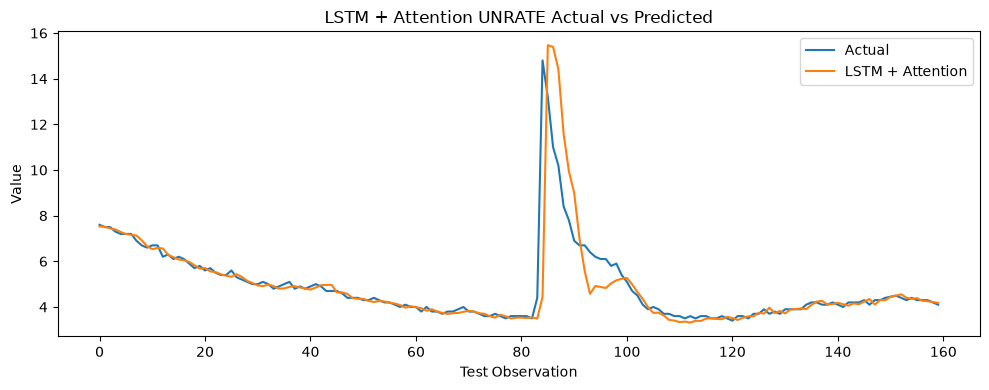

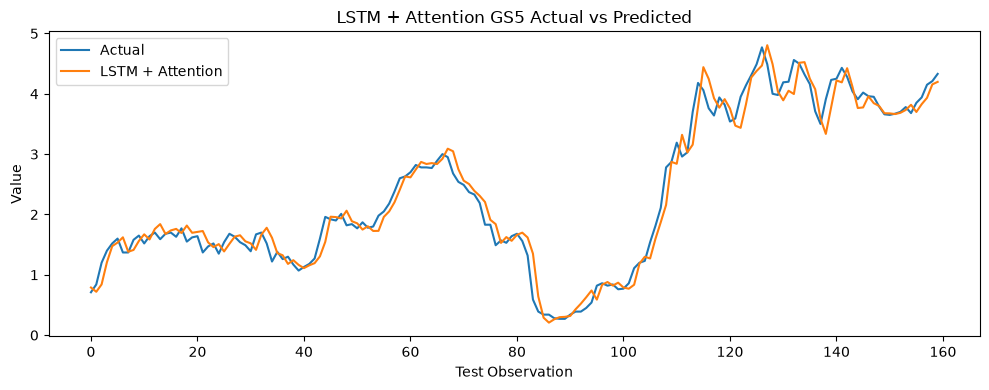

In [44]:
for series_name in ["UNRATE", "GS5"]:

    seed = get_median_seed(
        series_name
    )

    actual = y_test_store[
        series_name
    ]

    predicted = predictions_store[
        (series_name, seed)
    ]

    plt.figure(
        figsize=(10, 4)
    )

    plt.plot(
        actual,
        label="Actual"
    )

    plt.plot(
        predicted,
        label="LSTM + Attention"
    )

    plt.title(
        f"LSTM + Attention {series_name} Actual vs Predicted"
    )

    plt.xlabel(
        "Test Observation"
    )

    plt.ylabel(
        "Value"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

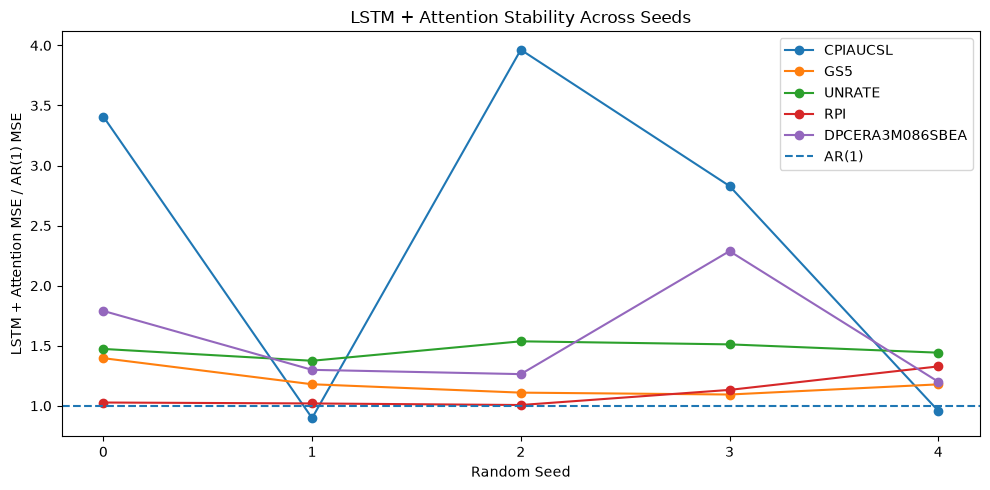

In [45]:
plot_results = all_results.copy()

plot_results["Relative MSE"] = (
    plot_results["LSTM Attention MSE"]
    /
    plot_results["AR(1) MSE"]
)


plt.figure(
    figsize=(10, 5)
)

for name in series_names:

    subset = plot_results[
        plot_results["Series"] == name
    ]

    plt.plot(
        subset["Seed"],
        subset["Relative MSE"],
        marker="o",
        label=name
    )


plt.axhline(
    y=1.0,
    linestyle="--",
    label="AR(1)"
)

plt.xlabel(
    "Random Seed"
)

plt.ylabel(
    "LSTM + Attention MSE / AR(1) MSE"
)

plt.title(
    "LSTM + Attention Stability Across Seeds"
)

plt.xticks(
    SEEDS
)

plt.legend()

plt.tight_layout()

plt.show()

In [46]:
lag_labels = [
    "t-12",
    "t-11",
    "t-10",
    "t-9",
    "t-8",
    "t-7",
    "t-6",
    "t-5",
    "t-4",
    "t-3",
    "t-2",
    "t-1"
]


average_attention = {}

for name in series_names:

    seed = get_median_seed(
        name
    )

    attention = attention_store[
        (name, seed)
    ]

    average_attention[name] = (
        attention.mean(axis=0)
    )

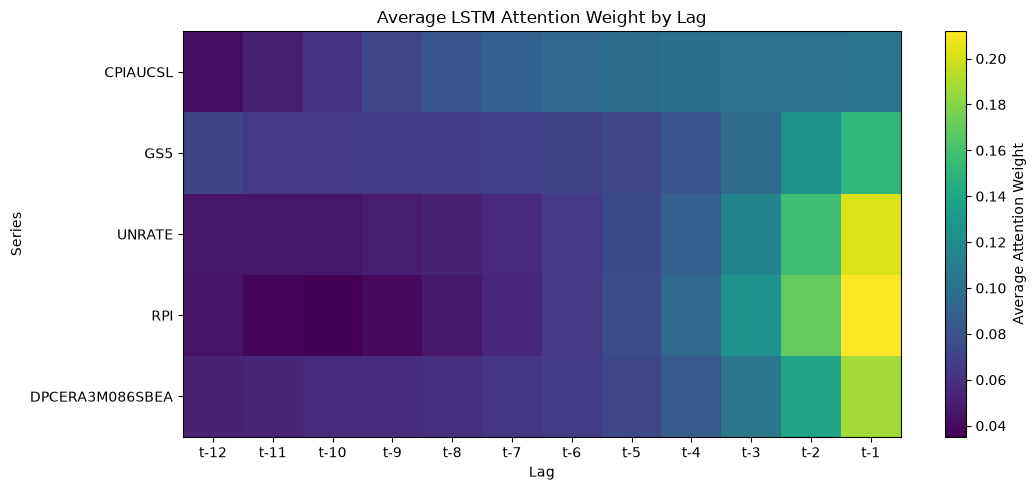

In [47]:
attention_matrix = np.array([
    average_attention[name]
    for name in series_names
])


plt.figure(
    figsize=(11, 5)
)

image = plt.imshow(
    attention_matrix,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Average Attention Weight"
)

plt.xticks(
    range(12),
    lag_labels
)

plt.yticks(
    range(len(series_names)),
    series_names
)

plt.xlabel(
    "Lag"
)

plt.ylabel(
    "Series"
)

plt.title(
    "Average LSTM Attention Weight by Lag"
)

plt.tight_layout()

plt.show()

In [48]:
for name in series_names:

    weights = average_attention[
        name
    ]

    ranked_indices = np.argsort(
        weights
    )[::-1]

    print(
        f"\n{name}"
    )

    for idx in ranked_indices[:3]:

        print(
            f"{lag_labels[idx]}: "
            f"{weights[idx]:.4f}"
        )


CPIAUCSL
t-1: 0.1039
t-2: 0.1027
t-3: 0.1014

GS5
t-1: 0.1517
t-2: 0.1235
t-3: 0.0974

UNRATE
t-1: 0.2022
t-2: 0.1577
t-3: 0.1148

RPI
t-1: 0.2119
t-2: 0.1696
t-3: 0.1242

DPCERA3M086SBEA
t-1: 0.1875
t-2: 0.1381
t-3: 0.1052


In [49]:
final_results = (
    all_results
    .groupby("Series")
    .agg(
        AR_MSE=(
            "AR(1) MSE",
            "first"
        ),

        LSTM_MSE_Mean=(
            "LSTM Attention MSE",
            "mean"
        ),

        LSTM_MSE_Std=(
            "LSTM Attention MSE",
            "std"
        )
    )
    .reset_index()
)

final_results

,Series,AR_MSE,LSTM_MSE_Mean,LSTM_MSE_Std
0,CPIAUCSL,0.571411,1.377858,0.807204
1,DPCERA3M086SBEA,1.835406,2.877901,0.854618
2,GS5,0.038561,0.045941,0.004666
3,RPI,227844.000000,251214.081250,30871.261941
4,UNRATE,0.773805,1.135596,0.048917
